<a href="https://colab.research.google.com/github/ChinthakindhiNishitha/DeepLearining/blob/main/week3(MLP%2CGD).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate

Learning Rate: 0.001 Final Loss: 5.166673368979993
Learning Rate: 0.01 Final Loss: 5.166666666666667


/tmp/ipykernel_1853/1886749211.py:32: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Learning Rate: 0.05 Final Loss: 5.166666666666667
Learning Rate: 0.1 Final Loss: 5.166666666666667
Learning Rate: 0.5 Final Loss: 5.166666666666667


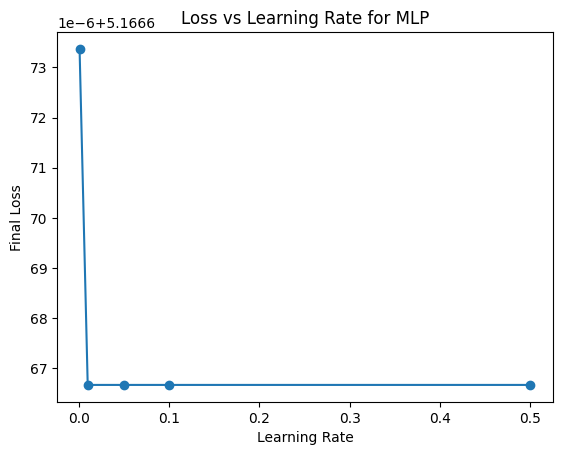

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------
train_dataset = h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r")
test_dataset = h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r")

X_train = np.array(train_dataset["train_set_x"][:])
y_train = np.array(train_dataset["train_set_y"][:])

X_test = np.array(test_dataset["test_set_x"][:])
y_test = np.array(test_dataset["test_set_y"][:])

# --------------------------------------------------
# Preprocess Data
# --------------------------------------------------
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

input_size = X_train.shape[1]

# --------------------------------------------------
# Activation Functions
# --------------------------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# --------------------------------------------------
# Training Function
# --------------------------------------------------
def train_mlp(learning_rate, epochs=1000):

    np.random.seed(1)

    hidden_size = 64
    output_size = 1

    # Weights and Bias Initialization
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))

    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))

    for epoch in range(epochs):

        # Forward Propagation
        Z1 = np.dot(X_train, W1) + b1
        A1 = sigmoid(Z1)

        Z2 = np.dot(A1, W2) + b2
        A2 = sigmoid(Z2)

        # Loss (Mean Squared Error)
        loss = np.mean((y_train - A2) ** 2)

        # Backpropagation
        dA2 = (A2 - y_train)
        dZ2 = dA2 * sigmoid_derivative(A2)

        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * sigmoid_derivative(A1)

        dW1 = np.dot(X_train.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Weight Updates
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    return loss

# --------------------------------------------------
# Learning Rates to Test
# --------------------------------------------------
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]
final_losses = []

for lr in learning_rates:
    loss = train_mlp(lr)
    final_losses.append(loss)
    print("Learning Rate:", lr, "Final Loss:", loss)

# --------------------------------------------------
# Plot Loss vs Learning Rate
# --------------------------------------------------
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate for MLP")
plt.show()

Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.

Epoch: 0 Loss: 6.889335379356132


/tmp/ipykernel_1853/2317938683.py:34: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


Epoch: 100 Loss: 5.166666666666667
Epoch: 200 Loss: 5.166666666666667
Epoch: 300 Loss: 5.166666666666667
Epoch: 400 Loss: 5.166666666666667
Epoch: 500 Loss: 5.166666666666667
Epoch: 600 Loss: 5.166666666666667
Epoch: 700 Loss: 5.166666666666667
Epoch: 800 Loss: 5.166666666666667
Epoch: 900 Loss: 5.166666666666667


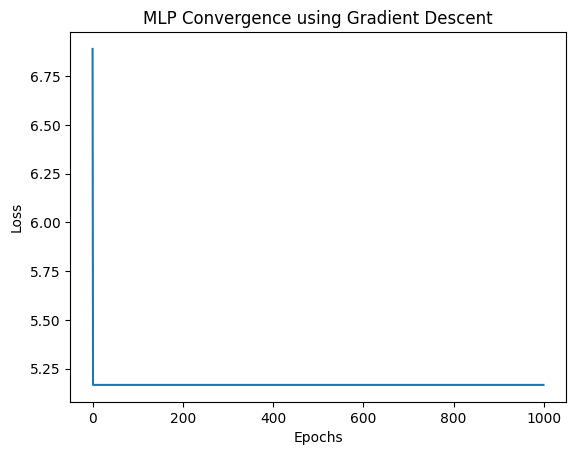

Test Accuracy: 16.666666666666664 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------
train_dataset = h5py.File("/content/drive/MyDrive/Signs_Data_Training.h5", "r")
test_dataset = h5py.File("/content/drive/MyDrive/Signs_Data_Testing.h5", "r")

X_train = np.array(train_dataset["train_set_x"][:])
y_train = np.array(train_dataset["train_set_y"][:])

X_test = np.array(test_dataset["test_set_x"][:])
y_test = np.array(test_dataset["test_set_y"][:])

# --------------------------------------------------
# Data Preprocessing
# --------------------------------------------------
X_train = X_train.reshape(X_train.shape[0], -1) / 255
X_test = X_test.reshape(X_test.shape[0], -1) / 255

y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

input_size = X_train.shape[1]
hidden_size = 64
output_size = 1

# --------------------------------------------------
# Activation Functions
# --------------------------------------------------
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

# --------------------------------------------------
# Initialize Weights and Bias
# --------------------------------------------------
np.random.seed(1)

W1 = np.random.randn(input_size, hidden_size)*0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)*0.01
b2 = np.zeros((1, output_size))

learning_rate = 0.05
epochs = 1000

losses = []

# --------------------------------------------------
# Gradient Descent Training
# --------------------------------------------------
for epoch in range(epochs):

    # Forward Propagation
    Z1 = np.dot(X_train, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # Loss
    loss = np.mean((y_train - A2)**2)
    losses.append(loss)

    # Backpropagation
    dA2 = A2 - y_train
    dZ2 = dA2 * sigmoid_derivative(A2)

    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1)

    dW1 = np.dot(X_train.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Gradient Descent Update
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 100 == 0:
        print("Epoch:", epoch, "Loss:", loss)

# --------------------------------------------------
# Plot Convergence
# --------------------------------------------------
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP Convergence using Gradient Descent")
plt.show()

# --------------------------------------------------
# Testing Accuracy
# --------------------------------------------------
Z1 = np.dot(X_test, W1) + b1
A1 = sigmoid(Z1)

Z2 = np.dot(A1, W2) + b2
A2 = sigmoid(Z2)

predictions = (A2 > 0.5)

accuracy = np.mean(predictions == y_test) * 100

print("Test Accuracy:", accuracy, "%")

Implement MLP with appropriate number of hidden layers and perceptrons to learn sign patterns

To implement a Multi-Layer Perceptron (MLP) to learn the Signs dataset, we will:

Load the dataset from .h5 files

Preprocess images

Flatten images (MLP requires 1-D input)

Build an MLP with hidden layers and perceptrons

Train the network

Evaluate accuracy

Your dataset has 6 classes of hand signs, so the output layer will have 6 neurons.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.1887 - loss: 4.6310 - val_accuracy: 0.1944 - val_loss: 2.8710
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2060 - loss: 2.1213 - val_accuracy: 0.3148 - val_loss: 1.8008
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2535 - loss: 1.8300 - val_accuracy: 0.2407 - val_loss: 1.7158
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2951 - loss: 1.7557 - val_accuracy: 0.2778 - val_loss: 1.7775
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4062 - loss: 1.5505 - val_accuracy: 0.3796 - val_loss: 1.5096
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4676 - loss: 1.3851 - val_accuracy: 0.4259 - val_loss: 1.5214
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4792 - loss: 1.3054 - val_accuracy: 0.4676 - val_loss: 1.3020
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5266 - loss: 1.2479 - val_accuracy: 0.3287 - val_loss

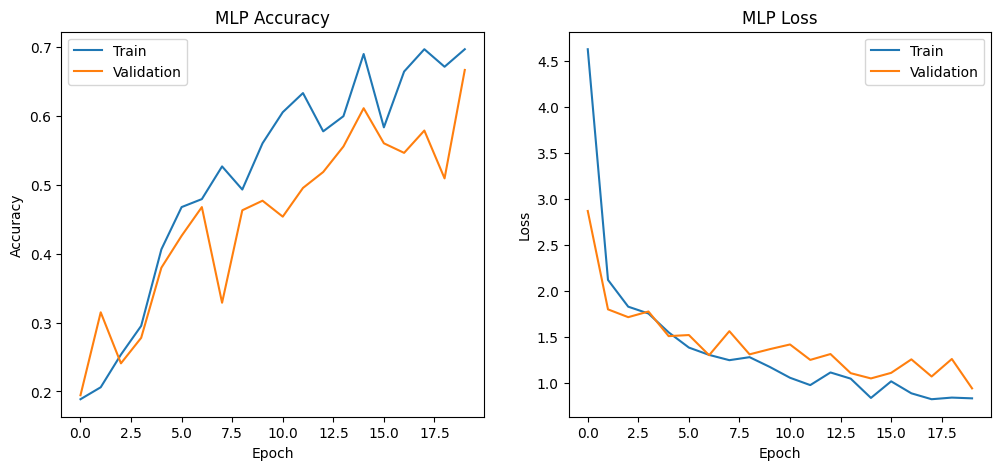

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7083 - loss: 0.8111 
Test Accuracy: 0.7083333134651184


In [ ]:
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------
train_data_path = "/content/drive/MyDrive/Signs_Data_Training.h5"
test_data_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"

with h5py.File(train_data_path, "r") as train_dataset:
    X_train = np.array(train_dataset["train_set_x"])
    Y_train = np.array(train_dataset["train_set_y"])

with h5py.File(test_data_path, "r") as test_dataset:
    X_test = np.array(test_dataset["test_set_x"])
    Y_test = np.array(test_dataset["test_set_y"])

# --------------------------------------------------
# Normalize Data
# --------------------------------------------------
X_train = X_train / 255.0
X_test = X_test / 255.0

# --------------------------------------------------
# Flatten Images for MLP
# --------------------------------------------------
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# --------------------------------------------------
# One Hot Encoding
# --------------------------------------------------
Y_train = tf.keras.utils.to_categorical(Y_train, num_classes=6)
Y_test = tf.keras.utils.to_categorical(Y_test, num_classes=6)

# --------------------------------------------------
# Create MLP Model
# --------------------------------------------------
mlp_model = tf.keras.Sequential([

    tf.keras.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(256, activation='relu'),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(6, activation='softmax')
])

# --------------------------------------------------
# Compile Model
# --------------------------------------------------
mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --------------------------------------------------
# Train Model
# --------------------------------------------------
history = mlp_model.fit(
    X_train,
    Y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# --------------------------------------------------
# Plot Training Performance
# --------------------------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("MLP Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("MLP Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

# --------------------------------------------------
# Evaluate Model
# --------------------------------------------------
test_loss, test_acc = mlp_model.evaluate(X_test, Y_test)

print("Test Accuracy:", test_acc)

### Build a Convolutional Neural Network (CNN) Model

For image classification tasks, Convolutional Neural Networks (CNNs) are generally more effective than MLPs because they can automatically learn hierarchical features from the spatial structure of images. The previous MLP model flattened the image data, losing this crucial spatial information. Below, I'll define and train a simple CNN model.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def create_cnn(learning_rate=0.001):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(6, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("CNN model defined.")

CNN model defined.


### Train and Evaluate the CNN Model

Now, let's train the new CNN model using the original (non-flattened) `X_train` and `X_test` data.

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step - accuracy: 0.1817 - loss: 1.7986 - val_accuracy: 0.3704 - val_loss: 1.7781
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.2685 - loss: 1.7273 - val_accuracy: 0.2685 - val_loss: 1.6512
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - accuracy: 0.3854 - loss: 1.5084 - val_accuracy: 0.5509 - val_loss: 1.2863
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.5162 - loss: 1.2476 - val_accuracy: 0.6528 - val_loss: 1.0355
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - accuracy: 0.5822 - loss: 1.0767 - val_accuracy: 0.6667 - val_loss: 0.8855
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.6146 - loss: 0.9870 - val_accuracy: 0.7917 - val_loss: 0.7478
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 0.6933 - loss: 0.8165 - val_accuracy: 0.8241 - val_loss: 0.5890
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.7257 - loss: 0.7360 - val_accuracy: 0.8009 - val_

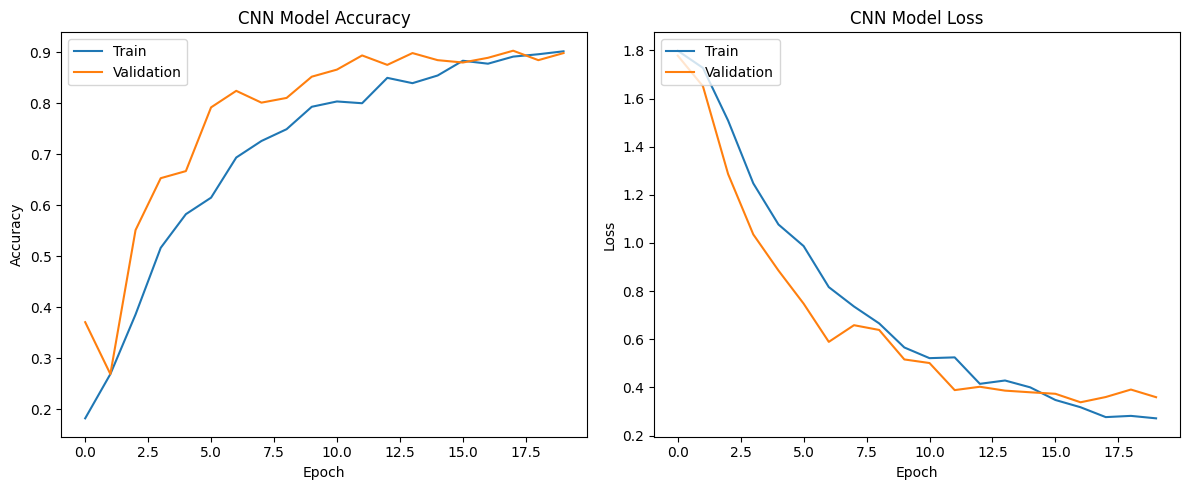

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9333 - loss: 0.2063

CNN Test Accuracy: 0.9333
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

CNN Predicted class (first 5 samples): [0 0 0 5 1]
Actual class (first 5 samples): [0 0 0 5 1]


In [ ]:
import h5py
import numpy as np
import tensorflow as tf # Ensure tf is available for to_categorical
import matplotlib.pyplot as plt # Ensure plt is available for plotting

# Paths to datasets
train_data_path = "/content/drive/MyDrive/Signs_Data_Training.h5"
test_data_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"

# Open training file and load data
with h5py.File(train_data_path, "r") as train_dataset:
    X_train = np.array(train_dataset["train_set_x"])
    Y_train = np.array(train_dataset["train_set_y"])

# Open testing file and load data
with h5py.File(test_data_path, "r") as test_dataset:
    X_test = np.array(test_dataset["test_set_x"])
    Y_test = np.array(test_dataset["test_set_y"])

# Normalize image data
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
Y_train_one_hot = tf.keras.utils.to_categorical(Y_train, num_classes=6)
Y_test_one_hot = tf.keras.utils.to_categorical(Y_test, num_classes=6)

# Create and train CNN model
cnn_model = create_cnn(learning_rate=0.001)

# Using X_train and X_test directly, as they are already in image format (batch, height, width, channels)
history_cnn = cnn_model.fit(
    X_train,
    Y_train_one_hot,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# Plotting the training history for the CNN model
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# Evaluate the CNN model on the test set
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test, Y_test_one_hot)
print(f"\nCNN Test Accuracy: {test_acc_cnn:.4f}")

# Look at predicted and actual classes for the CNN model
cnn_prediction = cnn_model.predict(X_test[:5])
print("\nCNN Predicted class (first 5 samples):", np.argmax(cnn_prediction, axis=1))
print("Actual class (first 5 samples):", np.argmax(Y_test_one_hot[:5], axis=1))

In [ ]:
import h5py
import numpy as np

# Paths to datasets
train_data_path = "/content/drive/MyDrive/Signs_Data_Training.h5"
test_data_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"

# Open training file and load data
with h5py.File(train_data_path, "r") as train_dataset:
    X_train = np.array(train_dataset["train_set_x"])
    Y_train = np.array(train_dataset["train_set_y"])

# Open testing file and load data
with h5py.File(test_data_path, "r") as test_dataset:
    X_test = np.array(test_dataset["test_set_x"])
    Y_test = np.array(test_dataset["test_set_y"])

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (1080, 64, 64, 3)
Y_train shape: (1080,)
X_test shape: (120, 64, 64, 3)
Y_test shape: (120,)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened shape:", X_train_flat.shape)

Flattened shape: (1080, 12288)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

In [ ]:
def create_mlp(learning_rate=0.001):

    model = Sequential([
        Dense(512, activation='relu', input_shape=(12288,)),
        Dropout(0.3),

        Dense(256, activation='relu'),
        Dropout(0.3),

        Dense(6, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.1640 - loss: 11.4202 - val_accuracy: 0.1528 - val_loss: 1.9765
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.1703 - loss: 2.1735 - val_accuracy: 0.1667 - val_loss: 1.7897
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.1867 - loss: 1.7918 - val_accuracy: 0.1713 - val_loss: 1.7920
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.1581 - loss: 1.7920 - val_accuracy: 0.1713 - val_loss: 1.7923
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.1639 - loss: 1.7921 - val_accuracy: 0.1713 - val_loss: 1.7924
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.1653 - loss: 1.7922 - val_accuracy: 0.1713 - val_loss: 1.7926
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.1657 - loss: 1.7917 - val_accuracy: 0.1296 - val_loss: 1.7929
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.1665 - loss: 1.7909 - val_accuracy: 0.1296 

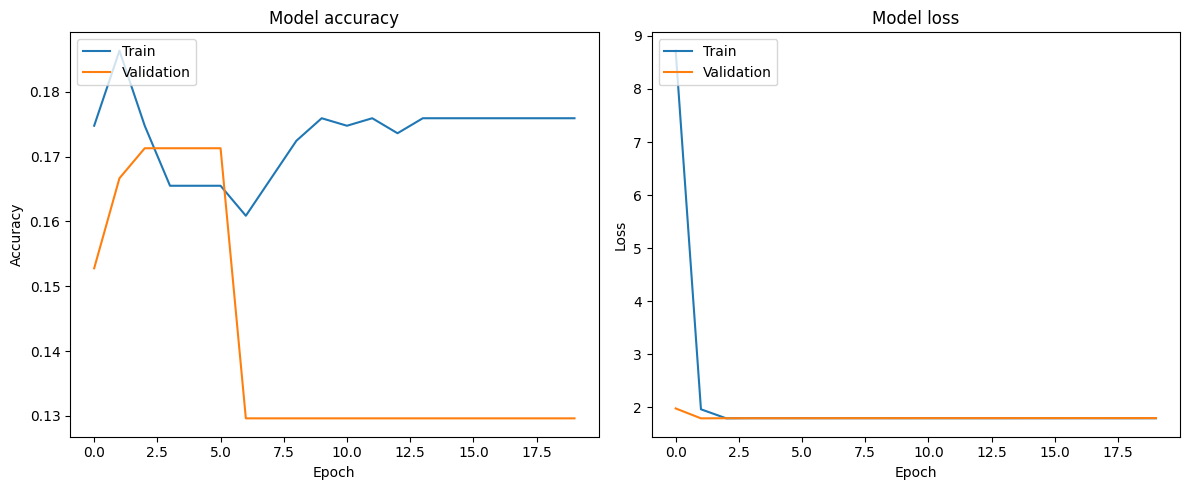

In [ ]:
Y_train_one_hot = tf.keras.utils.to_categorical(Y_train, num_classes=6)
Y_test_one_hot = tf.keras.utils.to_categorical(Y_test, num_classes=6)

model = create_mlp(learning_rate=0.001)

history = model.fit(
    X_train_flat,
    Y_train_one_hot, # Use one-hot encoded labels here
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# Plotting the training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test_flat, Y_test_one_hot)

print("Test Accuracy:", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1562 - loss: 1.7929
Test Accuracy: 0.1666666716337204


In [ ]:
learning_rates = [0.01, 0.001, 0.0001]

results = {}

for lr in learning_rates:
    print("\nTraining with LR =", lr)

    model = create_mlp(learning_rate=lr)

    model.fit(
        X_train_flat,
        Y_train_one_hot,
        epochs=15,
        batch_size=32,
        verbose=0
    )

    loss, acc = model.evaluate(X_test_flat, Y_test_one_hot, verbose=0)
    results[lr] = acc

print("\nResults:")
for lr, acc in results.items():
    print(f"Learning Rate {lr}: Accuracy = {acc:.4f}")


Training with LR = 0.01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with LR = 0.001

Training with LR = 0.0001

Results:
Learning Rate 0.01: Accuracy = 0.1667
Learning Rate 0.001: Accuracy = 0.1667
Learning Rate 0.0001: Accuracy = 0.3167


In [ ]:
epochs_list = [10, 30, 50]

for ep in epochs_list:
    print("\nEpochs =", ep)

    model = create_mlp(0.001)

    model.fit(
        X_train_flat,
        Y_train_one_hot,
        epochs=ep,
        batch_size=32,
        verbose=0
    )

    loss, acc = model.evaluate(X_test_flat, Y_test_one_hot, verbose=0)
    print("Accuracy:", acc)


Epochs = 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.1666666716337204

Epochs = 30
Accuracy: 0.1666666716337204

Epochs = 50
Accuracy: 0.1666666716337204


In [ ]:
prediction = model.predict(X_test_flat[:5])
print("Predicted class:", np.argmax(prediction, axis=1))
print("Actual class:", np.argmax(Y_test_one_hot[:5], axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted class: [0 0 0 0 0]
Actual class: [0 0 0 5 1]
